<div class="alert alert-block alert-danger">
    <b> Unraveling the cytoskeletal architecture of cancer cells: a novel computational approach to predict cell fate - CODE</b> 
    
 **3 - CYTOSKELETON PREPROCESSING**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
# IMPORTS
import os
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
import sys
sys.path.append(os.path.abspath('..'))
from packageCYSK.importing import *
from packageCYSK.preprocessingCYTO import *

print('📚 All libraries successfully imported 📚')

📚 All libraries successfully imported 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [2]:
# Define dataset folder.
folder      = os.path.dirname(os.getcwd()) + "\\Datasets\\Set 1-a-tubulin_Sofia"

# Import images from CYTO, NUCL and RGB folders.
options     = ["CYTO","NUCL","RGB"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

#data['CYTO_PRE'] = pd.read_pickle(folder + "\\CYTO_PRE\\CYTO_PRE.pkl") 

>>> [CYTO] added.
>>> [NUCL] added.
>>> [RGB] added.


In [3]:
data['CYTO']

,Path,Name,Label,Label 2,Resolution,Image,Image Size
11,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_11_WT_None.tif,WT,None.tif,"(1, 0.16125, 0.16125)","[[5366, 5542, 7214, 10072, 13142, 16186, 19740...","(1040, 1388)"
16,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_16_Mock_None.tif,Mock,None.tif,"(1, 0.16125, 0.16125)","[[2940, 4180, 5138, 5004, 3456, 2304, 1488, 19...","(1040, 1388)"
18,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_18_Mock_None.tif,Mock,None.tif,"(1, 0.16125, 0.16125)","[[962, 126, 36, 78, 320, 180, 36, 36, 92, 36, ...","(1040, 1388)"
20,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_20_Mock_None.tif,Mock,None.tif,"(1, 0.16125, 0.16125)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1040, 1388)"
30,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_30_WT_None.tif,WT,None.tif,"(1, 0.16125, 0.16125)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1040, 1388)"
34,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_34_NoTransfection_None.tif,NoTransfection,None.tif,"(1, 0.16125, 0.16125)","[[4044, 1698, 534, 146, 36, 0, 0, 0, 0, 22, 78...","(1040, 1388)"
36,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_36_NoTransfection_None.tif,NoTransfection,None.tif,"(1, 0.16125, 0.16125)","[[24326, 21696, 12804, 3640, 646, 92, 22, 0, 0...","(1040, 1388)"
38,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_38_NoTransfection_None.tif,NoTransfection,None.tif,"(1, 0.16125, 0.16125)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(1040, 1388)"
40,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_40_Del38-46_None.tif,Del38-46,None.tif,"(1, 0.16125, 0.16125)","[[22, 22, 56, 92, 146, 236, 250, 202, 180, 202...","(1040, 1388)"
42,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_42_Del38-46_None.tif,Del38-46,None.tif,"(1, 0.16125, 0.16125)","[[23336, 21704, 23670, 30358, 35747, 32764, 33...","(1040, 1388)"


<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**1.** Select an image.

**2.** Perform cytoskeleton preprocessing to the selected image. Tune the necessary parameters. Once satisfied with the results, save the textures and skeletons on ```data['CYTO_PRE']```. 

**3.** If you have a dataset of images, repeat this process with another image. In the end, ```data['CYTO_PRE']``` must be filled with cytoskeletons (textures and skeletons) identified from multiple images. 

**4.** Save the final dataframe.

<div class="alert alert-block alert-info">
    
 **SELECT IMAGE**
    
</div>

In [3]:
def dropdown_image_eventhandler(change):
    global idx
    idx = dropdown_image.value
    lab = data['CYTO']['Label'][dropdown_image.value]
    print('Image ' + str(idx) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Image:' , options = ['...'] + list(data['CYTO'].index))
dropdown_image.observe(dropdown_image_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Image:', options=('...', '11', '16', '18', '20', '30', '34', '36', '38', '40', '4…

Image 9 (WT) selected.
Image 11 (WT) selected.


<div class="alert alert-block alert-info">
    
 **CYTOSKELETON PREPROCESSING**
    
</div>

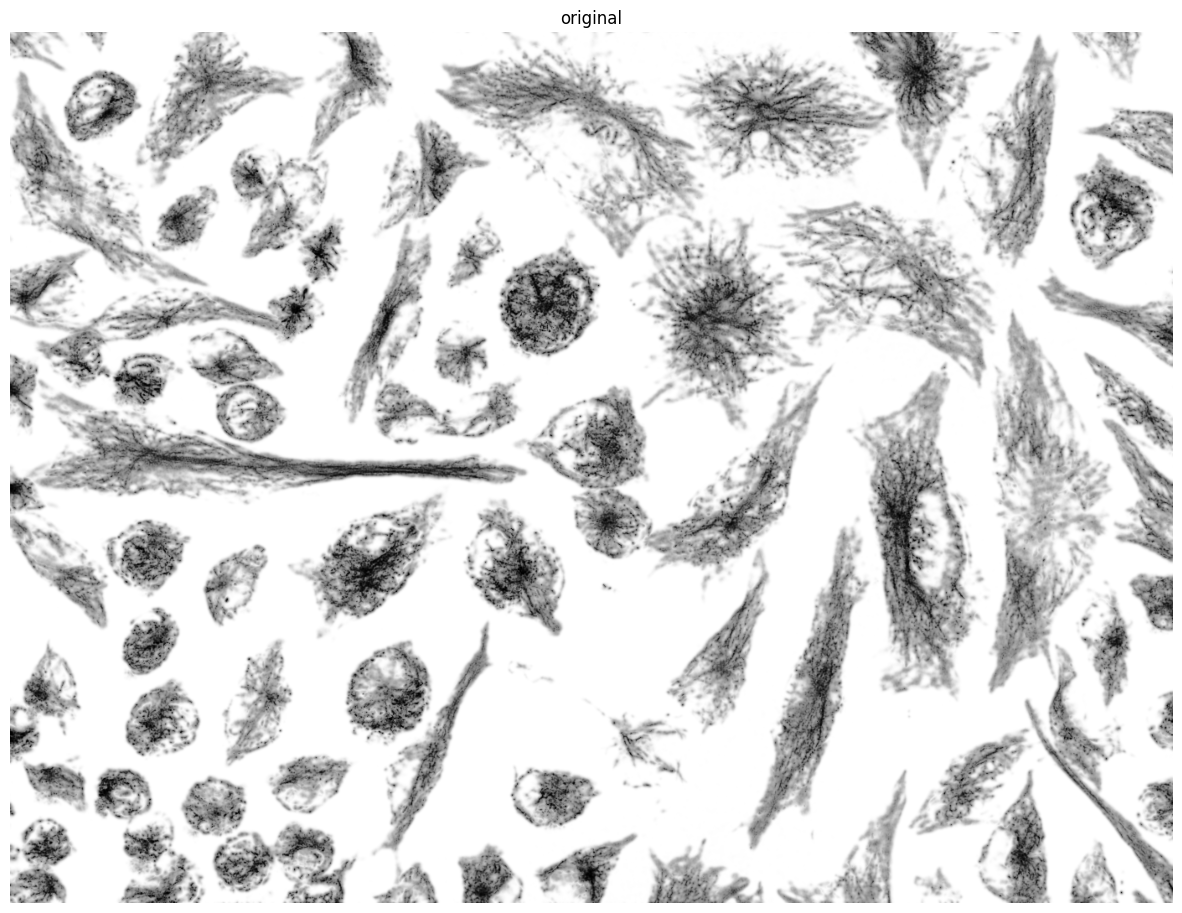

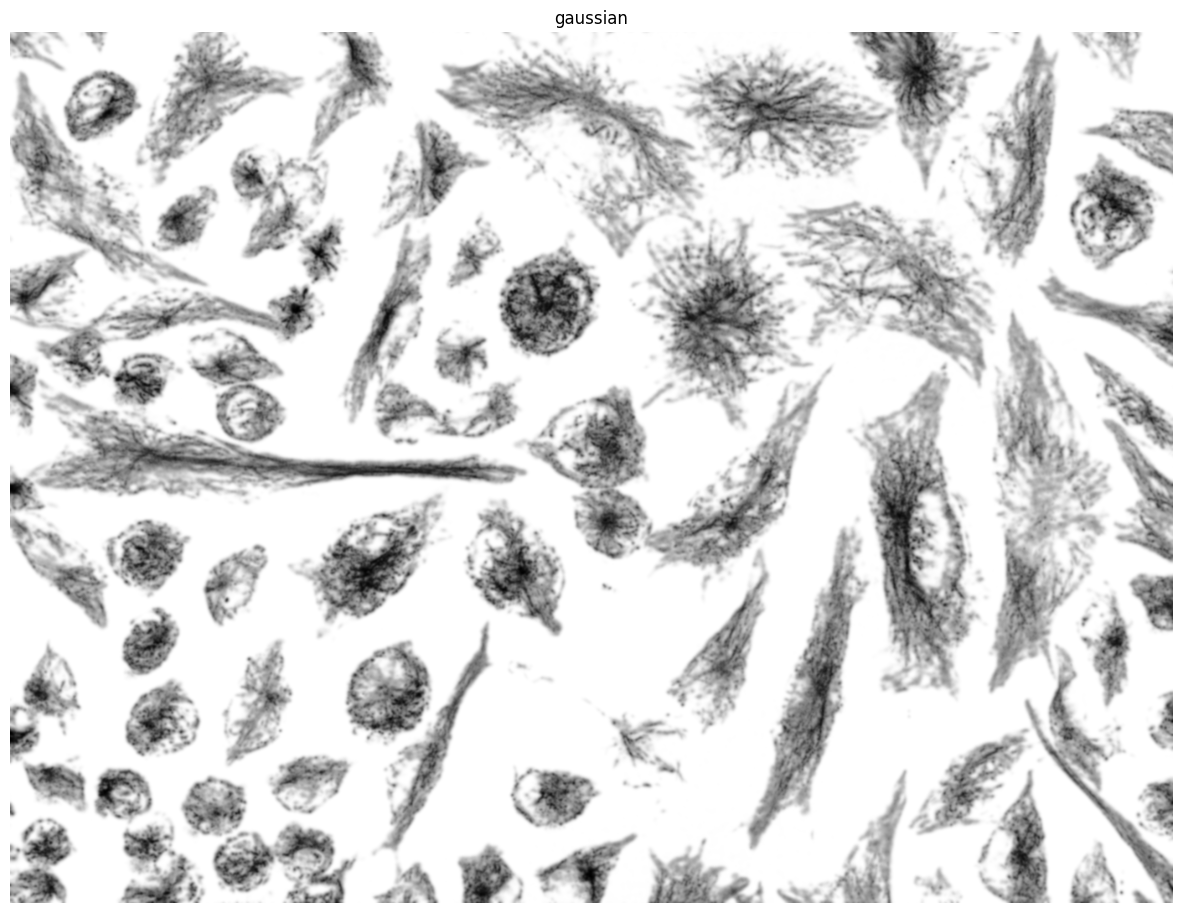

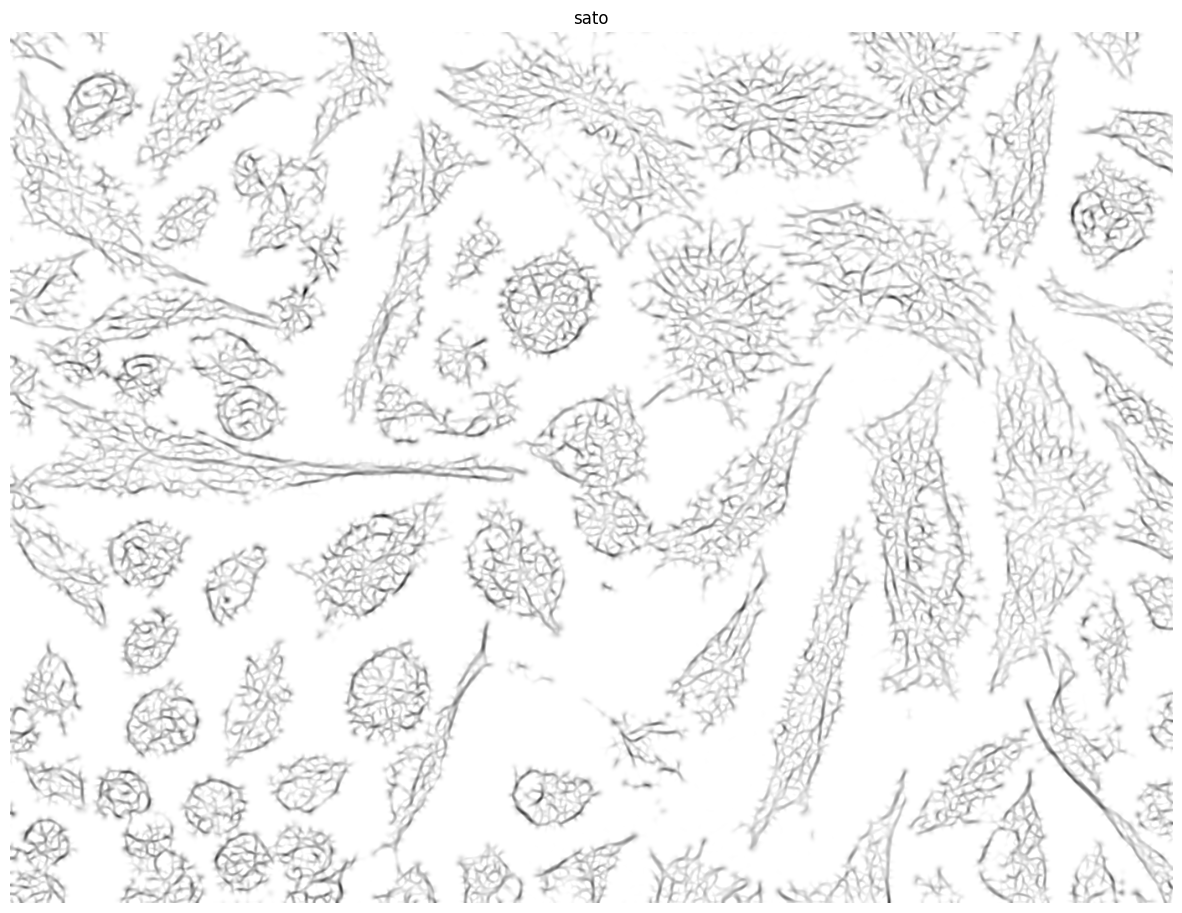

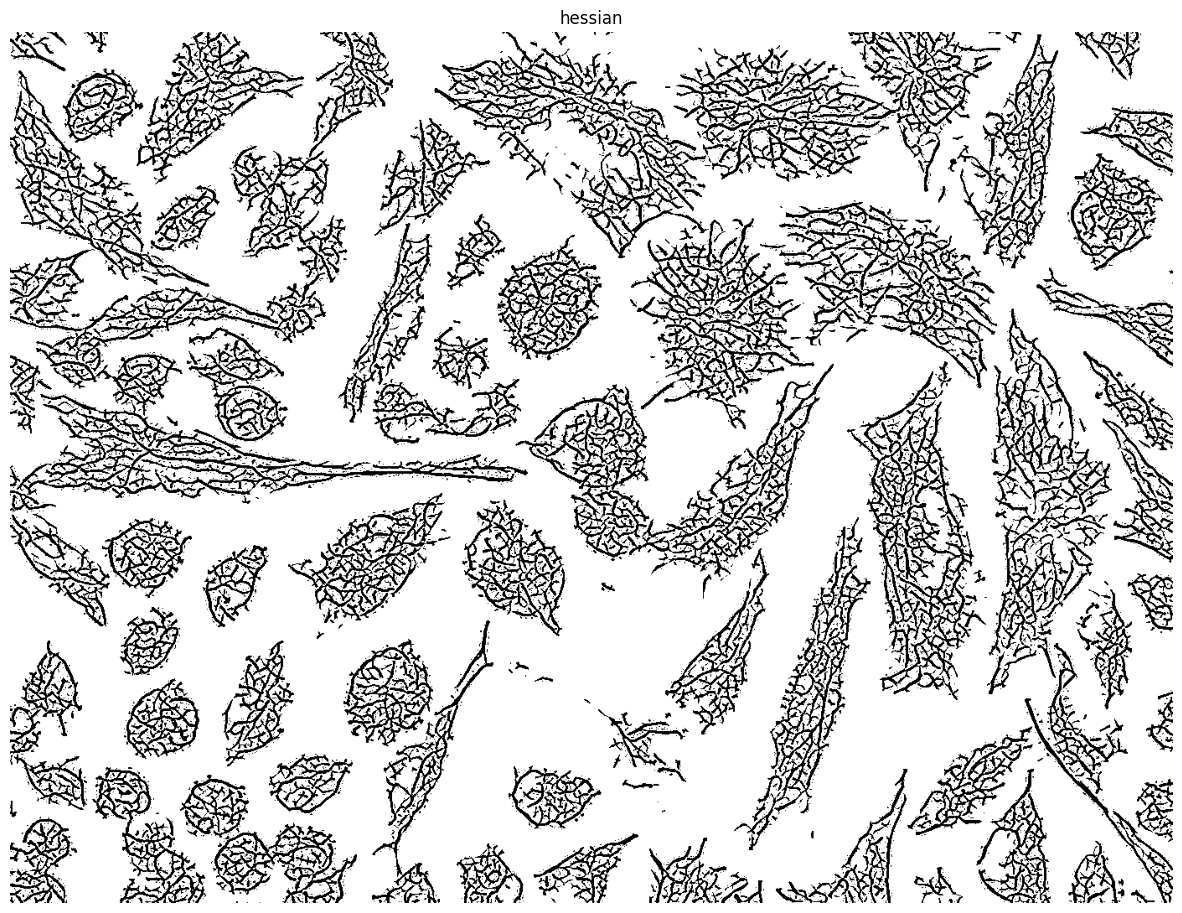

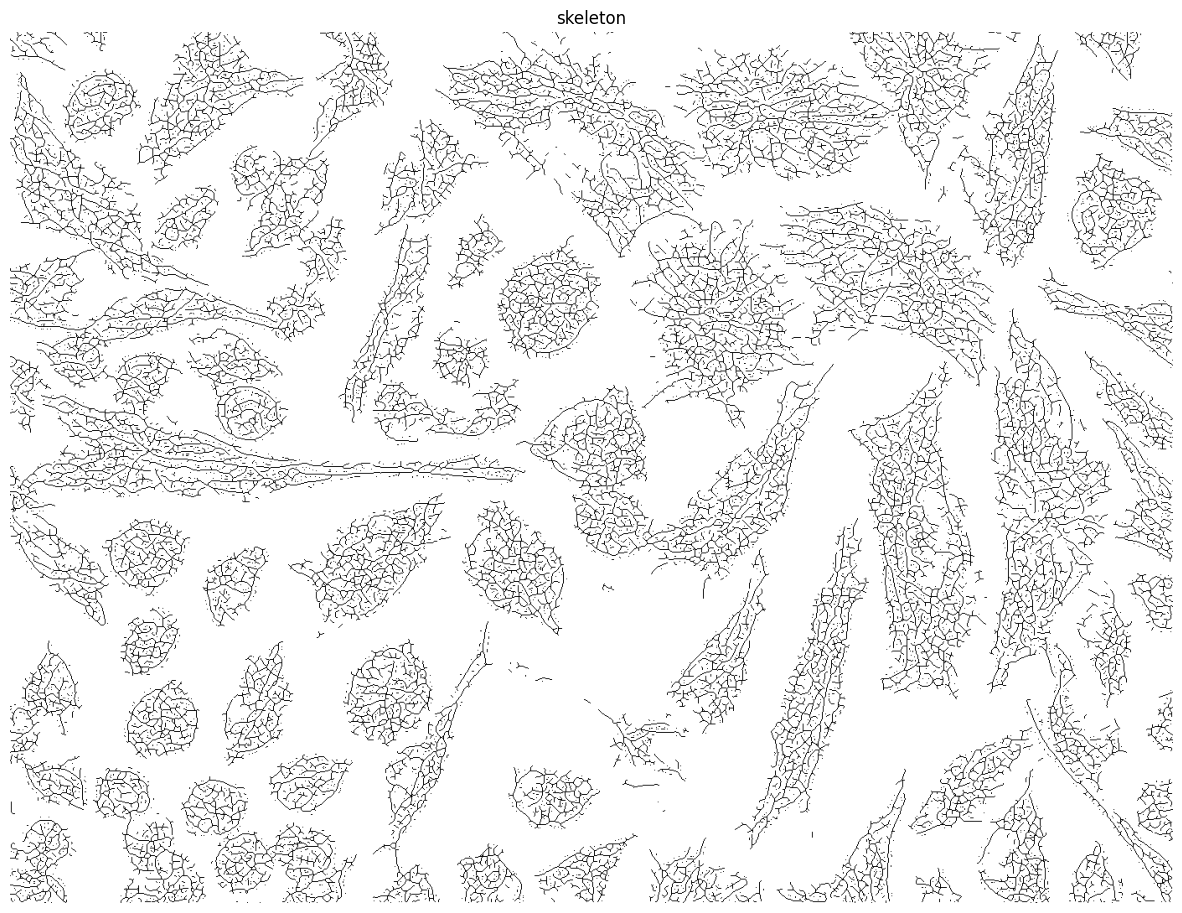

In [5]:
data['CYTO_PRE'] = cytoskeleton_preprocessing(rowCYTO = data['CYTO'].loc[idx],
                                           parameters = {'gau_sigma': 1,
                                                        'sato_sigma': 2,
                                                        'hess_sigma': 0.34},
                                                 plot = True,
                                                 save = False)[0] #save=folder+"\\" + str(image_id))

In [6]:
data['CYTO_PRE']

,Path,Name,Img Index,Label,Image Size,Texture,Skeleton
9,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_9_WT_None.tif,9,WT,"(1040, 1388)","[[0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
11,C:\Users\diogo\OneDrive - Universidade de Lisb...,MTs_11_WT_None.tif,11,WT,"(1040, 1388)","[[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


<div class="alert alert-block alert-info">
    
 **SAVE DATAFRAME**
    
</div>

In [6]:
data['CYTO_PRE'].to_pickle(folder + "//CYTO_PRE//CYTO_PRE_TEST.pkl")

---